# Assignment 1
## use this template!

This is the Notebook template that you would need for submitting your Assignment 1. Follow the order of this Notebook in reporting. If that is not followed, the assignment is not passed, hence resulting in 0 points.

The objective for this assignment is to build classification model to classify different types of network attacks in the CICIDS2017 dataset.
 - See Assignment 1 in Moodle for more detailed information

In general, when you get going with the assignment, it is good to note, that your codes would not (most probably) be such that you would run them on one machine and hence that your code would be just one file. Rather, right at the beginning, start planning together a skeleton for your code that serves as starting point for every group member. Then you divide among your group, which classification algorithm is handled by whom. Possibly by defining then more precisely which exact hyperparameters and pipeline steps you would utilize for that particular model. Read through this Notebook template and I believe you start to get the idea of how you could start approaching this assignment!

Below, I have provided topics which need to be answered below it. Do not change the order.

---

## 1. The Group 
- List briefly the group name, group member names and the study groups for the group members
## Group 22
- Jenna Kiviaho, Lotta Kauppinen, Marjaana Koski, Jani Laakso, Aleksi Savukoski

---

## 2. Contributions for the group members
Notice, basically everybody need to be able to do every step required. Of course, it may be that the group will work on the skeleton for the trainings together. Remember to say that if so. But if somebody is clearly not knowledgeable on, say, PCA and has not done anything with that, the group must make that clear here. In a way, that will become clear below with the results but that needs to be said here also.
- Explain the  of each group member.

| Group member name | Contibution |
| :--- | :--- |
| First Name, Last Name | Example: Did study all the steps for the pre-processing for example, was conducting the trainings and testing for kNN,<br> Was considering hyper parameter k and PCA, ran experiment w/o SMOTE also|
| Aleksi Savukoski | kNN training and testing (PCA, SMOTE, k, MinMax Scaler), creating the base of the skeleton |
| Lotta Kauppinen | Studied the SVMs and performed testing with only the baseline, PCA, SMOTE and PCA + SMOTE. Based on the results created Scaler comparison between StandardScaler vs MinMaxScaler. Small changes to the skeleton, because of errors that occured in the training stage. Studying the Naive Bayes and creating the code.|
| Jenna Kiviaho | Code for splitting 60/20/20 |
| Marjaana Koski | Decision Tree |
| Jani Laakso | Random Forest |




---

---

## 3. Use of AI
- Explain, how did you utilize AI to help you with the assignment?
- Each member does reporting they status individually

| Group member name | Contibution |
| :--- | :--- |
| First Name, Last Name | Example: I did not use AI at all|
| Aleksi Savukoski | Claude helps with code and explains step by step how and why the code works. |
| Lotta Kauppinen | Sparred with AI on how to make the code perform faster. Some of the suggestions worked and some of them not. AI helped to translate my thoughts of the results in to english. |
|  |  |
|  |  |
|  |  |

---

## 4. Dataset, Splitting the dataset
- How is the data sampled for the training, validation and testing dataset?

- How did you make sure everyone is using the same data?



In [1]:
# Basic libraries:

import numpy as np
import pandas as pd
import sklearn
import imblearn
import xgboost
import matplotlib
import seaborn

from sklearn.model_selection import train_test_split

---

In [2]:
df_original = pd.read_csv("data/cicids2017_cleaned.csv", low_memory=False) # Remember to put the correct csv-file to the data-folder
df_100 = df_original.sample(n=100_000, random_state=42)

In [3]:
# Comparing the sample dataset to the original one

counts_original = df_original["Attack Type"].value_counts()
percentages_original = df_original["Attack Type"].value_counts(normalize=True)

counts_100 = df_100["Attack Type"].value_counts()
percentages_100 = df_100["Attack Type"].value_counts(normalize=True)

comparison = pd.DataFrame({
    "Row count original" : counts_original, 
    "Count-% original": percentages_original.round(5)*100,
    "Row count sample file" : counts_100, 
    "Count-% sample file": percentages_100.round(5)*100})

print(comparison)

                Row count original  Count-% original  Row count sample file  \
Attack Type                                                                   
Normal Traffic             2095057            83.112                  83081   
DoS                         193745             7.686                   7673   
DDoS                        128014             5.078                   5115   
Port Scanning                90694             3.598                   3574   
Brute Force                   9150             0.363                    377   
Web Attacks                   2143             0.085                     92   
Bots                          1948             0.077                     88   

                Count-% sample file  
Attack Type                          
Normal Traffic               83.081  
DoS                           7.673  
DDoS                          5.115  
Port Scanning                 3.574  
Brute Force                   0.377  
Web Attacks           

In [4]:
df_100.to_csv("cleaned_100k.csv", index=False)

In [5]:
# The dataset and dataframe to be used

df = pd.read_csv("cleaned_100k.csv", low_memory=False)

The original dataset contained over 2.3 million rows. The original CSV file was sampled with Pandas to 100 000 items with random state of 42. If the original dataframe based on cicids2017_cleaned.csv would be read in, with random state = 42 the sample dataframe would be exactly the same.

 In dataset cicids2017_cleaned.csv there are 7 unique attack types, it is a paramount to have each type represented in the sample file. This way only the train-test model can learn about more rare attack type classes. For performance and computational purposes, randomly chosen 100 000 rows from the original set were chosen.

The comparison between original dataset and sample file is represented in this table:
| Attack Type     | Row Count (Original) | Percent % (Original) | Row Count (Sample) | Percent % (Sample) |
|-----------------|-----------------------|------------------------|---------------------|----------------------|
| Normal Traffic  | 2 095 057             | 83.112                 | 83 081              | 83.081               |
| DoS             |   193 745             | 7.686                  | 7 673               | 7.673                |
| DDoS            |   128 014             | 5.078                  | 5 115               | 5.115                |
| Port Scanning   |    90 694             | 3.598                  | 3 574               | 3.574                |
| Brute Force     |     9 150             | 0.363                  |   377               | 0.377                |
| Web Attacks     |     2 143             | 0.085                  |    92               | 0.092                |
| Bots            |     1 948             | 0.077                  |    88               | 0.088                |

The percentages of each attack type are well represented in the dataset, as it mimics the original dataset's propotions.

The dataframe was exported into CSV file named cleaned_100k.csv. This CSV is also used as a basis for the assignment's dataframe, which confirms, that the assignment is based solely on the sampled dataset and dataframe.

In [6]:
# Defining target
y = df['Attack Type']
X = df.drop('Attack Type', axis = 1)

# First to split data into train and test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

# Split train again into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify = y_train_val)


print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(60000, 52)
(20000, 52)
(20000, 52)


---

### Shared skeleton for the group

The cell below is a **shared skeleton** every group member uses as the starting point for their own classifier. It locks down the decisions that must be identical across the team so results are comparable in Section 10:

- the same 10 features (`FEATURES`),
- the same pipeline order (Scaler → PCA → SMOTE → Classifier),
- the same scoring metric for GridSearchCV (`f1_macro`, because accuracy is misleading under 83% class imbalance),
- the same `run_experiment()` helper so every algorithm is evaluated the same way and logged into `all_results`.

Each member only fills in their classifier and its `param_grid`; an example for kNN is shown at the bottom of the cell (commented out).

Note: SMOTE is wrapped by **imblearn's** Pipeline, not sklearn's, so synthetic samples are only generated inside each CV training fold, never inside the fold used for scoring. Using sklearn's Pipeline here would silently inflate scores.

In [7]:
# =====================================================================
#  SHARED SKELETON - all group members use this as the starting point.
#  Only the classifier in 'clf' and the 'param_grid' change per algorithm.
# =====================================================================

# Extra imports beyond the ones in the top imports cell
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# Agreed 10-feature list
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 3
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True, use_scaler=True, use_lda=False, use_poly=False):

    steps = []

    # 1. scaling
    if use_scaler:
        steps.append(("scaler", StandardScaler()))

    if use_poly:
        steps.append(("poly", PolynomialFeatures(degree=2))) # 29.4. added for polynomial features testing

    # 2. SMOTE (only training data)
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))
    # 3.1 Use LDA 
    if use_lda:
        steps.append(("lda", LDA()))

    # 3.2 OR, use PCA (valinnainen)
    if use_pca:
        steps.append(("pca", PCA()))

    # 4. model
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1
    )

    grid.fit(X_train_sel, y_train)

    y_val_pred = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{label} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation acc: {val_acc:.4f}, f1: {val_f1:.4f}")
    print(f"Test acc: {test_acc:.4f}, f1: {test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label": label,
        "grid": grid,
        "best_params": grid.best_params_,
        "val_acc": val_acc,
        "val_f1_macro": val_f1,
        "test_acc": test_acc,
        "test_f1_macro": test_f1,
        "smote": use_smote,
        "pca": use_pca
    }

all_results = []


# =====================================================================
#  PER-MEMBER USAGE EXAMPLE (kNN - commented out)
#  Copy this block, swap in your own classifier + param_grid.
# =====================================================================
# from sklearn.neighbors import KNeighborsClassifier
#
# knn_grid = {
#     "pca__n_components": [4, 6, 8],
#     "clf__n_neighbors":  [3, 5, 7, 11],
#     "clf__weights":      ["uniform", "distance"],
# }
#
# all_results.append(
#     run_experiment(KNeighborsClassifier(), knn_grid,
#                    label="kNN + SMOTE + PCA")
# )
# all_results.append(
#     run_experiment(KNeighborsClassifier(), knn_grid,
#                    label="kNN no-SMOTE baseline", use_smote=False)
# )

Fitting 3 folds for each of 4 candidates, totalling 12 fits


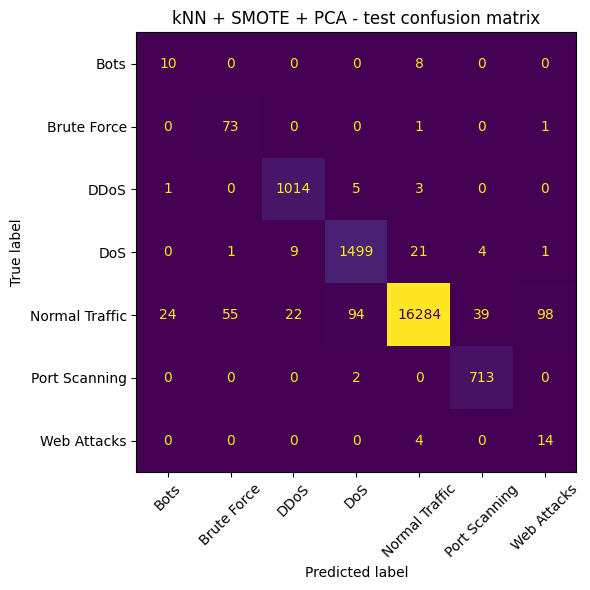


=== kNN + SMOTE + PCA ===
Best params : {'clf__n_neighbors': 3, 'clf__weights': 'distance', 'pca__n_components': 8}
Val  acc=0.9801  f1_macro=0.7569
Test acc=0.9804  f1_macro=0.7429
                precision    recall  f1-score   support

          Bots      0.286     0.556     0.377        18
   Brute Force      0.566     0.973     0.716        75
          DDoS      0.970     0.991     0.981      1023
           DoS      0.937     0.977     0.956      1535
Normal Traffic      0.998     0.980     0.989     16616
 Port Scanning      0.943     0.997     0.969       715
   Web Attacks      0.123     0.778     0.212        18

      accuracy                          0.980     20000
     macro avg      0.689     0.893     0.743     20000
  weighted avg      0.987     0.980     0.983     20000



In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid_lite = {
    "pca__n_components": [6, 8],
    "clf__n_neighbors":  [3, 5],
    "clf__weights":      ["distance"],
}

all_results.append(
    run_experiment(KNeighborsClassifier(), knn_grid_lite,
                   label="kNN + SMOTE + PCA")
)

In [9]:
#AS 27.4. Commented out for testing purposes, as the full grid takes a long time to run. The above "lite" version is used instead.
# from sklearn.neighbors import KNeighborsClassifier
#
# knn_grid = {
#     "pca__n_components": [4, 6, 8],
#     "clf__n_neighbors":  [3, 5, 7, 11],
#     "clf__weights":      ["uniform", "distance"],
#}

# all_results.append(
#     run_experiment(KNeighborsClassifier(), knn_grid,
#                    label="kNN + SMOTE + PCA")
#)

## 5. Label variable

This is a **multi-class classification** problem with 7 classes in the `Attack Type` column:

| Class | Share of data |
| :--- | ---: |
| Normal Traffic | 83.08% |
| DoS | 7.67% |
| DDoS | 5.12% |
| Port Scanning | 3.57% |
| Brute Force | 0.38% |
| Web Attacks | 0.09% |
| Bots | 0.09% |

The dataset is **severely imbalanced** — Normal Traffic outnumbers Bots by roughly 1000:1. Because of this, we report **`f1_macro`** as our primary metric rather than raw accuracy. Accuracy is misleading here: a model that predicts "Normal Traffic" for every single row would still score ~83% accuracy while completely failing at its actual job (detecting attacks). `f1_macro` averages the F1-score across all 7 classes equally, so a model has to do well on the rare attack types to earn a good score.

For the same reason we apply **SMOTE** inside the training pipeline to synthetically oversample the minority classes during fitting (§7), and we use **`stratify=y`** when splitting so that every class is present in the train, validation, and test sets in the same proportions.

---

23.4. AS: Suggested features
## 6. Feature variables

The cleaned dataset contains 52 numeric feature columns. Rather than feed all of them to every model, the group agreed on a common set of **10 flow-level features** chosen to cover the main information axes a network-traffic classifier needs. Using the same 10 features across all 7 algorithms also makes the comparison in §10 meaningful — any performance differences come from the classifier, not from different feature sets.

**The 10 "agreed" features:**

| Feature | What it captures |
| :--- | :--- |
| Flow Duration | How long the connection lasted |
| Total Fwd Packets | Packet count in the forward direction (volume) |
| Total Length of Fwd Packets | Total bytes in the forward direction (volume) |
| Flow Bytes/s | Byte rate — high for DDoS, low for Port Scanning |
| Flow Packets/s | Packet rate — separates scanning from bulk traffic |
| Fwd Packet Length Mean | Average size of forward packets |
| Bwd Packet Length Mean | Average size of backward packets — asymmetry is a strong attack signal |
| Packet Length Mean | Overall packet size average |
| Packet Length Std | Variability in packet size — uniform sizes suggest automated/attack traffic |
| Average Packet Size | Summary size statistic |

**Reasoning behind the selection:**

1. **Coverage of five information axes.** Network attacks differ along *timing* (Flow Duration), *volume* (packet and byte totals), *rate* (bytes/s, packets/s), *packet size distribution* (means and std), and *directional asymmetry* (forward vs backward statistics). Each axis is represented.
2. **Forward + backward directions.** Many attacks are highly asymmetric — Port Scanning sends lots of small SYN packets forward and receives little back; DoS floods one direction. Keeping both `Fwd` and `Bwd` statistics preserves this signal.
3. **Ratios and rates, not just counts.** Absolute counts depend on how long the flow ran. `Flow Bytes/s` and `Flow Packets/s` are normalized and comparable across flow durations.
4. **Avoid redundant/derived columns.** The full dataset contains many near-duplicate or derived columns (subflow totals, init window sizes for each direction, etc.). Picking a compact set reduces multicollinearity, speeds up training, and — importantly for kNN — mitigates the curse of dimensionality.
5. **Algorithm-neutral features.** All 10 are continuous numeric columns that work directly with scaling, PCA, and SMOTE without special encoding.


---

## 7. SMOTE
- Explain shortly how SMOTE took place in your tests. Report your overall findings for SMOTE already here even though you may or may not say something on SMOTE later in the Results section. I say this like this because, the results section may become populated with lots of results already otherwise, so this might be your opportunity to keep that section simpler.


As mentioned, the used dataset is highly skewed. This imbalance is tried to improve with a particular focus on the implementation of Synthetic Minority Over-sampling Technique, or SMOTE. By increasing the representation of these rare classes in the training data, SMOTE forces the ML models to learn more about these classes' patterns. As a result, the amount of False Negatives for attack classes is expected decrease.

#### SMOTE in SVMs
##### SMOTE increased the macro F1-score which shows us that the model was able to detect minority attack classes also. However, this lowered the overall accuracy. This is due to the model becoming more sensitive to minority classes and less biased toward the majority class. The overall results were not the greatest: Accuracy: 0.7438 (≈ 74.38%) and F1-score (macro): 0.4988, compared to other models. 

In [ ]:
# Param grid WITH PCA
# svm_param_grid_pca = {
    # "pca__n_components": [5, 8],
    # "clf__C": [0.1, 1, 10],
    # "clf__kernel": ["rbf"],
    # "clf__gamma": ["scale", "auto"]
#}

# Param grid WITHOUT PCA
# svm_param_grid_no_pca = {
    # "clf__C": [0.1, 1, 10],
    # "clf__kernel": ["rbf"],
    # "clf__gamma": ["scale", "auto"]
# }

# 3. SMOTE only
# all_results.append(run_experiment(
    # SVC(),
    # svm_param_grid_no_pca,
    # "SVM + SMOTE (no PCA)",
    # use_smote=True,
    # use_pca=False
# ))

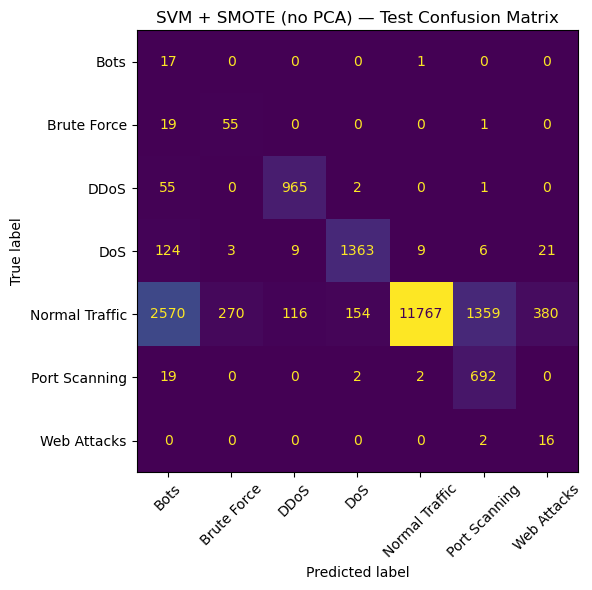

#### SMOTE in Naive Bayes
##### SMOTE increased the results slightly, but with or without SMOTE, Naive Bayes model performed poorly on this particular dataset. The baseline showed accuracy (≈ 17.5%) and F1-score (macro): 0.1564. With SMOTE the numbers were accuracy: 0.2799 (≈ 28.0%) and F1-score (macro): 0.2947. 

In [ ]:
# nb_param_grid = {
    # "clf__var_smoothing": [1e-9, 1e-8]
# }

# 3. SMOTE
# all_results.append(run_experiment(
    # GaussianNB(),
    # nb_param_grid,
    # label="NB + SMOTE",
    # use_smote=True,
    # use_pca=False,
    # use_scaler=True
# ))

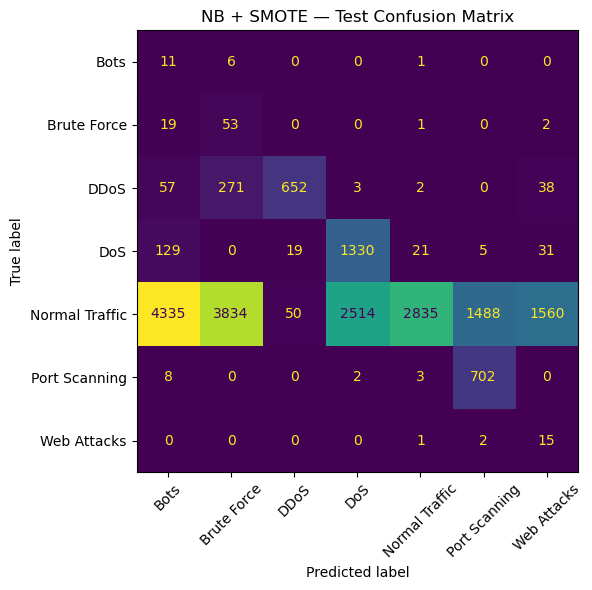

### SMOTE in decision tree models
When studying macro average f1 or macro average precision, out of all seven decision tree training models using SMOTE did not enhance precision or f1. On the contrary, using SMOTE created the worst classes for these metrics. This is a result of increased amount of false positives in minority classes.

Opposite results were gained, when macro average recall was investigated. As SMOTE oversamples smaller classes, also decision tree classifies minor classes easier. At the same time, the model begins to misclassify some Normal Traffic samples as attacks, increasing false negatives for the majority class.

Below is a table of all runs, highlighting the use of SMOTE, and the highest score of each metric.

| Model                                      | Test F1 | Accuracy | Macro Recall | Macro Precision |
|--------------------------------------------|------------|----------|--------------|------------------|
| DT + **no SMOTE** + no PCA + no scaler       |  **0.7941**  | **0.993**    | 0.783        | 0.811           |
| DT + **no SMOTE** + PCA + no scaler            |  0.7773      | 0.991    | 0.762        | **0.816**           |
| DT + **no SMOTE** + PCA + standard scaler      |  0.7644      | 0.989    | 0.756        | 0.775           |
| DT + **no SMOTE** + LDA + no scaler            |  0.7629      | 0.988    | 0.756        | 0.774           |
| DT + SMOTE + PCA + no scaler               |  0.7480      | 0.980    | **0.868**        | 0.707           |
| DT + SMOTE + PCA + standard scaler         |  0.7271      | 0.980    | 0.866        | 0.679           |
| DT + SMOTE + LDA + no scaler               |  0.7125      | 0.976    | 0.854        | 0.663           |


---

## 8. Scaling, Polyfeatures, PCA, LDA, Kernel PCA


- Similar to SMOTE above. You will most probably run lots of tests on your own separate Notebooks different from this group level submission Notebook.
- Again, the results section may become populated with lots of results already otherwise, so this might be your opportunity to keep that section simpler.
- Still say conclusions shortly, what worked, what not
- Paste here a code sample/snippet showing the main steps, their tested orders and settings you used for these. Yes, the code snipped may not be functional on this notebook, as this is supposed to be just snippet illustrating your working. Adding all, would probably make the document messy!
- So explain main effect these step had for your trainings. Did something work or not, so basically when did you got benefit from those.
- Which parameters did provide the best results in case of which algorithm


### Scaling

In preprocessing, scaling is a crucial step to normalize the data into common range. It is a mandatory step for distance-based models. Without scaling the model is prone to prioritize classes with large scales. In some cases, scaling might also improve some algorithms' performance.

The default scaling method in this study is standard scaling, or standardization. In standardization, the data is transformed so, that data is centered around 0 (this is the mean value) and standard deviation is 1. Another model used as an extra training parameter is min-max scaling. This model converts the data so, that all values fall between the range of 0 and 1.

#### SMVs and Scaling, Polyfeatures, PCA, LDA, Kernel PCA
SVM is based on distances and therefore it is crucial to use scaling. The Standard Scaler was determined the best choice for this model.

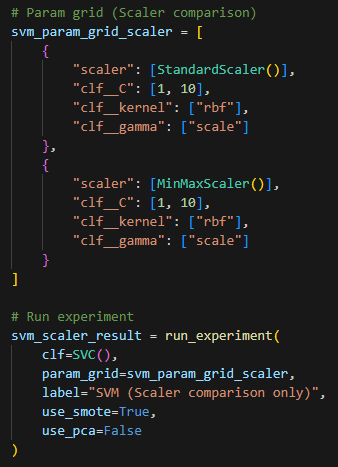

Polyfeatures and Kernel PCA were not tested with SVM, because of the RBF kernel that was used. 
Using PCA with SVM, showed no improvement on the results.
The SVM code was very time consuming and heavy on the computer (8 hours). Due to the lack of time, I was not able to perform the code with LDA.

#### Scaling in decision trees
Decision tree is not distance based model, but a model which makes decisions against threshold comparison. Therefore scaling is not a mandatory or even recommended step in the pipeline. To reduce the amount of needless data trainings, standardization was used for only two models. For the same reason, min-max scaling was not introduced to decision tree models.

In theory, scaling should not change the decision tree's results. But, in the pipeline, scaling is done first, and then SMOTE and/or PCA is applied. In these cases the original training data is altered. Therefore, the way scaled models performed worse might be due to the way PCA and/or SMOTE work, not scaling itself. All in all, the use of scaling is an unneccessary step in decision trees, though results between using the scales is illustrated below.


| Models with and without SMOTE                                     | Test F1 | Accuracy | Macro Recall | Macro Precision |
|--------------------------------------------|------------|----------|--------------|------------------|
| DT + no SMOTE + PCA + **no scaler**      |  **0.7773**      | **0.991**    | **0.762**        | **0.816**     |
| DT + no SMOTE + PCA + standard scaler      |  0.7644      | 0.989    | 0.756        | 0.775           |
| DT + SMOTE + PCA + **no scaler**           |  **0.7480**      | **0.980**    | **0.868**        | **0.707**           |
| DT + SMOTE + PCA + standard scaler         |  0.7271      | **0.980**    | 0.866        | 0.679           |

### Naive Bayes and Scaling, Polyfeatures, PCA, LDA, Kernel PCA
##### The results showed that the most useful preprocessing step is to use LDA. This creates a more clear structure, even though the results are not as good as with other classification algorithms.
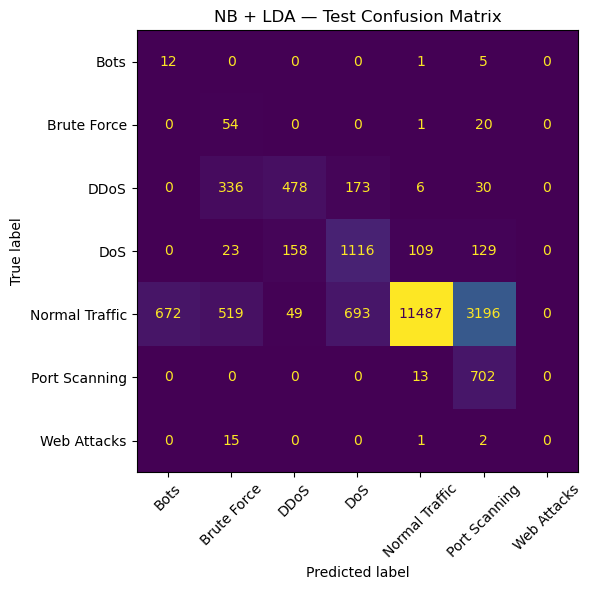
##### Naive Bayes did not benefit from scaling as the results are the exact same:
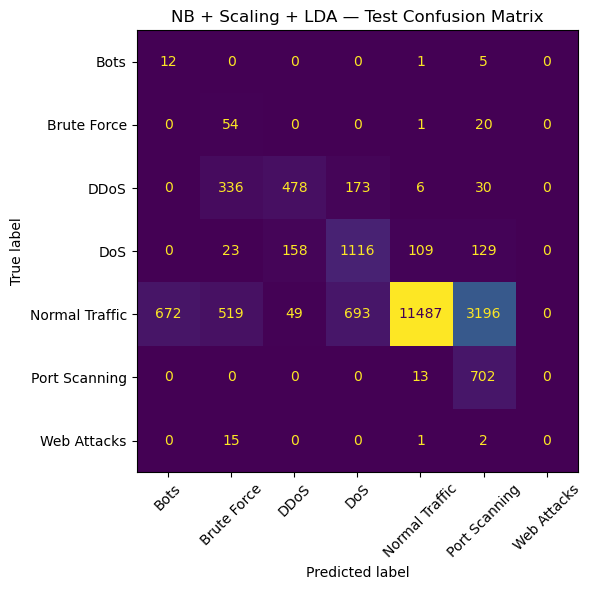
##### Naive Bayes is based on a "Independence" assumption which means that every feature in the dataset is independent of the others. Polynomial Features, PCA and Kernel PCA do not go well with this assumption. 


### PCA and LDA

The original dataset contained dozens of features, many of which were irrelevant or redundant. Even though the amount of features was decreased to 10, there still might be features which are highly correlated. Applying dimensionality reduction can help to reduce the model complexicity while important information is still preserved.

Principal component analysis (PCA) is one of many reduction techniques. It finds the directions where variance is largest among the data points. Original features are combined into uncorrelated  principal components, containing as much variance from the data as possible. 

Similar to PCA, linear discrimination analysis (LDA) is a dimensional reduction technique in ML. Unlike PCA, which focuses on features, LDA is a supervised technique and takes classes into account. It tries to separate the classes by finding a plane/line, where distance between classes is maximised, while variance inside the class is minimized. Finally, the calculated components are directions which separate classes most. Both LDA and PCA give weighted combinations of original features.

#### PCA and LDA in decision tree models

---

## 9. Training setups
- Provide snippets of code that would through Pipeline and GripSearchCV variables make it clear which hyperparameters did you cover, what where the order of steps for standardization, feature dimensionality reduction etc. Ok, maybe bit overlapping with the part 8. above but at least the classification algorithms were not covered there. 
- I wrote snippets(!) in plural form as for different members of the group, you may have needed to make adjustments to those variables depending on, for example, the classification algorithm that you personally have been working with.
- However, do not exaggerate. Keep the snippets concise and short, the point is to show and convince me that you have done what you were supposed to and you know what you were doing
- As mentioned at the end of the Assignment 1 description in Moodle, in addition to this Notebook, zip your personal working Notebooks were you show more functional code. However, I check these only if needed for some reason. So basically, the idea is to write here things so that I would not need to check those. So it is about the clarity of the submission in a way.
 

---

## 10. Classification Results and Best model/models
- Again, make sure you use same data for training, validation and testing.
- Collect your results then together here
- Provide accuracies and confusion matrices. Maybe selfevident, but the results need to be comparable for different algorithms. So present them that way also.
- You can also consider precision, recall and F1-score. At least Recall may be interresting to observe when comparing the performance with or without SMOTE
- What is then the best model/models, point that out
- What is then the setup (preprocessing steps, hyperparameter) that produced that best model(s)?


---

#### RESULTS:

| Model | Preprocessing | Accuracy | F1-score |
|-------|---------------|----------|----------|
| SVM   | Baseline      | 0.9281   | 0.3930   |
| SVM | PCA | 0.9271 | 0.3919 |
| SVM | SMOTE | 0.7438 | 0.4988 |
| SVM | SMOTE + PCA | 0.7431 | 0.4939 |
| SVM | Scaler comparison, winner: Standard Scaler | 0.7438 | 0.4988 |
| Naive Bayes | Baseline | 0.1746 | 0.1564 |
| Naive Bayes | Standard Scaler | 0.2944 | 0.2755 |
| Naive Bayes | SMOTE | 0.2799 | 0.2947 |
| Naive Bayes | PCA | 0.5991 | 0.3180 |
| Naive Bayes | LDA | 0.6925 | 0.3486 |
| Naive Bayes | Polynomial Features | 0.1603 | 0.1854 |
| Naive Bayes | Standard Scaler + LDA | 0.6925 | 0.3486 |
| Naive Bayes | Standard Scaler + LDA + SMOTE | 0.2964 | 0.2060 |
| Naive Bayes | Standard Scaler + PCA + SMOTE | 0.1700 | 0.1691 |

Finally, make sure for the last time that this documentation of yours would make sense for somebody who might continue your work with extended data later on.
